# SFINCS Demo

In this demo, we will practice building and creating a SFINCS model for the NJ coast from Sandy Hook to Asbury Park during Hurricane Sandy. The northern half (Sandy Hook spit + Sandy Hook Bay) is included so the offshore boundary can carry the alongshore gradient observed during Sandy, and so the NOAA Sandy Hook gauge falls inside the domain for validation.

## Data Sources

| Dataset | Source | File | Purpose |
|---------|--------|------|---------|
| **2010 USACE NCMP topobathy** | NOAA / USACE (pre-Sandy, NOAA ID 9456) | `data/elevation/usace_nj_2010_topobathy.tif` | 1 m **pre-Hurricane-Sandy** topobathy on the dune / beach / nearshore strip. Captures the dune state that existed on 2012-10-29 — before ~$1B of post-storm beach replenishment. NAVD88. |
| NOAA CUDEM 1/9" topobathy | NOAA NCEI northeast_sandy (2014–2018) | `data/elevation/cudem_asbury.tif` | ~3 m topobathy fill for inlets + shelf seaward of the dune line, where the 2010 NCMP product has NoData. NAVD88. |
| NJ 10-ft LiDAR DEM | NJ OGIS statewide mosaic (2014–2019) | `data/elevation/nj_10ft_dem.tif` | Inland topography where CUDEM has no data. |
| GEBCO 2026 | GEBCO global grid | `data/elevation/gebco_nj.tif` | ~450 m offshore tail (anything seaward of CUDEM). |
| **NOAA CO-OPS water levels** | NOAA Tides & Currents API (gauges 8518750, 8531680, 8534720, 8536110) | `data/gtsm/noaa_sandy_nj.nc` | Observed hourly water levels (m NAVD88) at four NJ/NY gauges spanning the boundary. Replaces an earlier GTSM-ERA5 hindcast that under-predicted Sandy's peak by ~1 m on the NJ shelf. Sandy Hook (8531680) failed mid-storm; The Battery (~5 km north) carries the peak. |
| ERA5 winds + pressure | Copernicus CDS (`reanalysis-era5-single-levels`) | `data/era5/era5_nj_sandy_2012_10_28_31.nc` | 10-m wind components and MSLP forcing (hourly, Oct 28–31 2012). |
| NLCD 2012 land cover | USGS/MRLC | `data/roughness/nlcd_2012.tif` | Manning's roughness reclass via `NLCD_SFBD_mapping.csv`. |

### Elevation merge logic (four-tier, top → bottom)

`setup_dep` and `setup_subgrid` fill the DEM in dataset order — later entries only fill NoData left by earlier ones:

1. **2010 USACE NCMP** (no filter) — pre-Sandy 1 m topobathy on the coastal strip. Takes priority where it has data: the surge-relevant surface (dunes, beach, surf zone) is the 2010 state, not the modern engineered state.
2. **CUDEM** — fills inlet channels + nearshore + shallow shelf where the NCMP strip ends.
3. **NJ 10-ft LiDAR** (`zmin=0.001`) — fills inland land. The `zmin` filter excludes LiDAR's hydroflattened water surfaces so they don't overwrite real channel depths underneath.
4. **GEBCO** — offshore tail for the deeper shelf.

> **Why pre-Sandy data?** This is a *hindcast* of Sandy. Modern topobathy products (e.g. the 2022 USACE DEM, post-2013 USGS CoNED) include beach replenishment and engineered dunes that didn't exist on 2012-10-29 — using them systematically under-predicts overtopping. The 2010 NCMP product is the closest pre-storm 1 m topobathy available for the NJ coast.

In [1]:
# Imports
import os
import subprocess
from datetime import datetime
from pathlib import Path

import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray
import xarray as xr
from hydromt._utils import log
from hydromt_sfincs import DATADIR, SfincsModel, utils
from shapely.geometry import Point



## Phase 1 — Static build

Everything here depends only on **geometry, topography, and roughness** — grid, elevation, mask, observation points, and the subgrid tables. It's the expensive part (the subgrid build spikes to ~13 GB RAM), but it's a **one-time cost**: the outputs are written to disk and SFINCS just reads them.

**Re-run Phase 1 only when one of these changes:** region/resolution, the elevation datasets or merge order, the roughness datasets or reclass table, `nr_subgrid_pixels`, or the mask `zmin`/boundary logic.

If you're only changing **forcing** (water level, wind, pressure, timing), skip straight to Phase 2 — it reopens this model from disk and never touches the subgrid build.

### 1. Initialize SfincsModel, set data library, and output folder

In [2]:
model_root = "../model"

log.initialize_logging()
log.set_log_level(log_level=30)  # Only errors and critical

# Add file handler to log to a file
log_file = Path(model_root) / "hydromt_sfincs.log"
logger = log._add_filehandler(log_file)

# Add data catalogs
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]

# Create model
sf = SfincsModel(
    data_libs=data_libs, root=model_root, mode="w+", write_gis=True
)


2026-05-18 13:13:50,018 - hydromt.model.model - model - WARNING - No region component found in components.


### 2. Specify grid

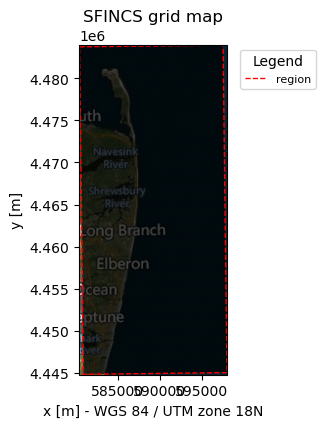

In [3]:
# Create grid from region.  50 m (was 100 m) so the 1 m topobathy data
# is sampled into a grid that can actually resolve the barrier-island
# dune line; subgrid pixels below give a ~3 m effective resolution.
sf.grid.create_from_region(
    region={"geom": "/home/zagreus/nj_sandy_sfincs/data/region.geojson"},
    res=50,
    rotated=True,
    crs="utm",
)

# Show model grid outline
_ = sf.plot_basemap(
    variable="grid",
    plot_region=True,
    bmap="sat",
    zoomlevel=10,
    grid_kwargs={"linewidth": 0.3},
)


### 3. Add elevation

2026-05-18 13:14:07,666 - hydromt.hydromt_sfincs.components.grid.elevation - elevation - WARNING - Interpolate elevation at 1 cells


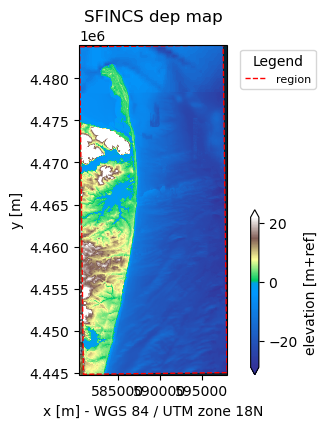

In [4]:
elevation_list = [
    {"elevation": "usace_nj_2010"},                # 1 m pre-Sandy topobathy: dunes, beach, surf zone
    {"elevation": "cudem_nj"},                     # 3 m fill: inlet channels + shelf
    {"elevation": "nj_10ft_dem", "zmin": 0.001},   # 3 m fill: inland (drop hydroflat water)
    {"elevation": "gebco_nj"},                     # 450 m offshore tail
]

sf.elevation.create(elevation_list=elevation_list, buffer_cells=1)

# Plot the merged topobathy (colour limits set between -25 m and +10 m to show NJ shelf)
_ = sf.plot_basemap(
    variable="dep",
    plot_region=True,
    bmap="sat",
    zoomlevel=10,
)

### 4. Make mask of activate and inactive cells

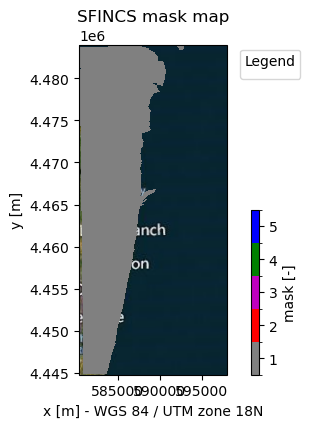

In [5]:
# All cells with elevation >= -10 m are considered active
# The NJ shelf is shallow, so -10 m captures it without going too far offshore
sf.mask.create_active(zmin=-10)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=10,
)

### 5. Update mask with boundary cells

Two boundary types are set on the perimeter of the active mask:
- **Water level (mask=2)** on the deep-ocean edge (`zmax=-1`) — where NOAA CO-OPS forcing is applied.
- **Outflow (mask=3)** on the lateral/inland edges at low elevation (`-1 ≤ zb ≤ 2 m`) — lets surge that propagates into back-bay channels (Shark River, Sandy Hook Bay) drain out of the domain instead of piling up against the model edge.

2026-05-18 13:14:09,764 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


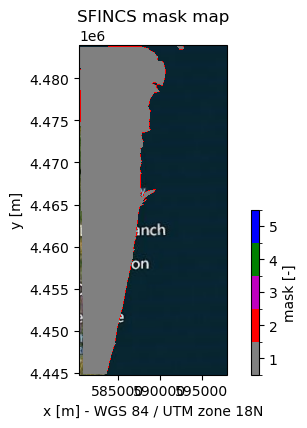

In [6]:
# Mark offshore edge cells (depth > 1 m) as water level boundary cells
sf.mask.create_boundary(
    btype="waterlevel",
    zmax=-1,
    reset_bounds=True,
)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

2026-05-18 13:14:10,718 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


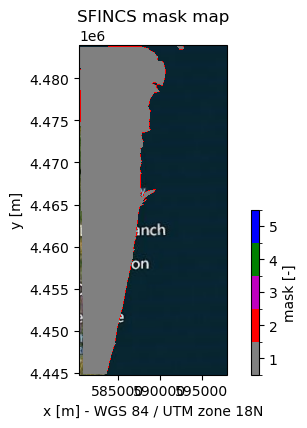

In [7]:
# Add outflow cells (mask=3) on the lateral/inland edges of the active mask.
# zmin/zmax restricts to channels/back-bay cells; high dune cells stay as
# regular interior land (no outflow needed). reset_bounds=False preserves
# the offshore water-level boundary set above.
sf.mask.create_boundary(btype="outflow", zmin=-1, zmax=2, reset_bounds=False)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

### 6. Add observation points

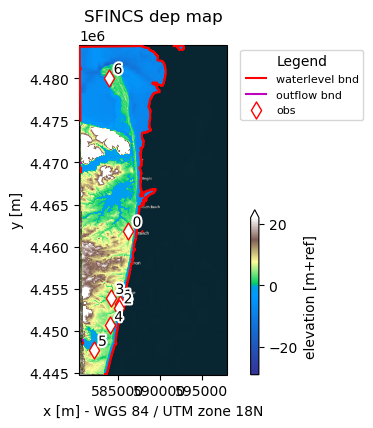

In [8]:
# Project obs points + the Sandy Hook NOAA gauge for validation. The Sandy
# Hook 8531680 gauge falls inside the domain — modeled zs(t) here vs the
# observed record (valid up to the gauge failure ~23:00 UTC 2012-10-29) is the
# cleanest single-point temporal check; the USGS HWMs (Phase 3) add the
# spatial check across the domain.
obs_gdf = gpd.read_file("../data/obs.geojson")
sandy_hook = gpd.GeoDataFrame(
    {"name": ["sandy_hook_gauge"]},
    geometry=[Point(-74.0091, 40.4669)],  # NOAA 8531680
    crs="EPSG:4326",
)
obs_all = gpd.GeoDataFrame(
    pd.concat([obs_gdf, sandy_hook], ignore_index=True),
    crs="EPSG:4326",
)
sf.observation_points.create(locations=obs_all, merge=False)

_ = sf.plot_basemap(
    variable="dep",
    plot_geoms=True,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=12,
)

### 7. Make subgrid derived tables

Subgrid tables bake elevation and roughness into per-cell lookup tables at higher effective resolution. SFINCS uses these directly and **ignores any standalone manningfile** when subgrid is active, so we set roughness here rather than as a separate model layer.

In [9]:
# NLCD → Manning reclass table (hydromt_sfincs built-in; SFBD-tuned — TODO: swap for CONUS table)
reclass_table = os.path.join(DATADIR, "lulc", "NLCD_SFBD_mapping.csv")

elevation_list = [
    {"elevation": "usace_nj_2010"},                # 1 m pre-Sandy topobathy: dunes, beach, surf zone
    {"elevation": "cudem_nj"},                     # 3 m fill: inlet channels + shelf
    {"elevation": "nj_10ft_dem", "zmin": 0.001},   # 3 m fill: inland (drop hydroflat water)
    {"elevation": "gebco_nj"},                     # 450 m offshore tail
]
roughness_list = [{"lulc": "nlcd_2012", "reclass_table": reclass_table}]

# nr_subgrid_pixels=8 (was 16) so the 50 m grid samples ~3 m effective —
# fine enough to capture the dune line from the 1 m USACE topobathy.
sf.subgrid.create(
    elevation_list=elevation_list,
    roughness_list=roughness_list,
    nr_subgrid_pixels=8,
    write_dep_tif=True,
    write_man_tif=True,
)

2026-05-18 13:14:14,459 - hydromt.gis.raster - raster - WARNING - The nodata value None is not in the reclass table.None will be used for the params.
2026-05-18 13:14:24,524 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 1127 subgrid pixels with default values
2026-05-18 13:14:39,957 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 391 subgrid pixels with default values
2026-05-18 13:14:49,690 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 6194 subgrid pixels with default values


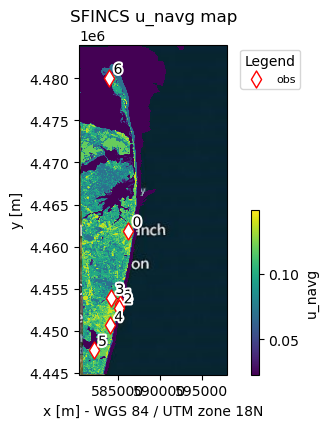

In [10]:
# Plot one of the 2D subgrid variables — u_navg is the representative depth for momentum fluxes
_ = sf.plot_basemap(
    variable=sf.subgrid.data["u_navg"],
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

In [11]:
# --- End of Phase 1: write the static model to disk ---
# Grid, elevation, mask, subgrid tables, and obs points are now on disk.
# None of this depends on forcing, so you don't need to rebuild it when
# iterating on water level / wind / pressure — Phase 2 reopens from here.
sf.write()

# Free the build-time memory. The data-catalog cache + source DEMs held
# ~10 GB resident after the build; Phase 2 opens a fresh handle and doesn't
# need any of it. (Restarting the kernel here works just as well.)
del sf
import gc; gc.collect()

7850

## Phase 2 — Forcing & run

Everything from here depends on **forcing**, not geometry: water level, wind, pressure, and the simulation time window. This is the cheap, fast-iterating half — no DEM loads, no subgrid build, ~30 s instead of ~10 min.

**Entry point:** the cell below reopens the static model from Phase 1 in `r+` mode. If you just ran Phase 1 in this same kernel it was `del`'d to free memory, so run this cell either way. Safe after a kernel restart — it only needs the imports cell near the top.

In [2]:
# --- Phase 2 entry point: reopen the static model from disk ---
# mode="r+" opens the existing Phase 1 model and allows updating it in place.
# Re-defined here (not just in the Phase 1 init cell) so this works as a
# standalone entry point after a kernel restart.
model_root = "../model"
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]

sf = SfincsModel(model_root, data_libs=data_libs, mode="r+")

2026-05-20 12:34:38,078 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/zagreus/nj_sandy_sfincs/data/data_catalog.yml


2026-05-20 12:34:38,093 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc2).


2026-05-20 12:34:38,093 - hydromt.model.model - model - WARNING - No region component found in components.


### 1. Add water level time-series as forcing

Observed NOAA CO-OPS hourly water levels in NAVD88, replacing an earlier GTSM-ERA5 hindcast that under-predicted Sandy's peak by ~1 m on the NJ shelf. The forcing file (`noaa_sandy_nj.nc`) holds **three complete-record gauges** — The Battery, Atlantic City, Cape May. **Sandy Hook (8531680) is excluded**: its gauge failed mid-storm (last valid 10-29 23:00), and feeding the NaN tail into the boundary collapses the northern forcing. The Battery (~5 km north, complete record, 3.42 m peak) anchors that latitude instead; the partial Sandy Hook record lives in `noaa_sandy_validation.nc` for validation only.

Two `water_level.create` arguments matter here: `merge=False` (replace the forcing rather than merge with whatever `r+` mode loaded from disk) and `buffer=100000` (wide enough to reach Atlantic City ~88 km south, so the boundary keeps Sandy's real alongshore gradient).

In [3]:
# Set the simulation period to cover Hurricane Sandy's landfall.
# tstart == tref so the model gets ~24 h of calm tide before Sandy arrives.
# Without that head-start, at the first step the boundary jumps from zsini=0
# to ~1.5 m (Battery is mid-tide on 10-29 00:00) and the model rings for an
# hour before settling — visible as a spike/oscillation in the Sandy Hook
# validation plot at the start of the run.
sf.config.update(
    {
        "tref": datetime(2012, 10, 28),
        "tstart": datetime(2012, 10, 28),
        "tstop": datetime(2012, 10, 31),
        "tspinup": 3600.0,    # smoothly ramp the boundary over the first hour
                              # instead of step-applying it (belt-and-suspenders
                              # on top of the 24 h of pre-storm tide above).
        "coriolis": 1,        # on: 40 N + sustained alongshore Sandy winds.
                              # Expect only a small correction though — with
                              # observed-gauge boundaries the regional Ekman
                              # setup is already in the BC; this just adds the
                              # setup generated within the ~40 km domain.
        "latitude": 40.32,    # domain-center latitude (deg). SFINCS needs this
                              # to compute the Coriolis parameter — without it
                              # the run log reports "Coriolis: no" even with
                              # coriolis=1 set. f-plane is fine at 40 km
                              # (Coriolis varies <5% across the domain).
        "advection": 1,       # advection term in the momentum equations. Already
                              # the hydromt-sfincs default (always written to
                              # sfincs.inp), so the run log has shown "Advection:
                              # yes" all along — set explicitly here for the
                              # record. Matters around the inlet and steep surge
                              # gradients, and is required once waves/IG are
                              # added later (per the Carolinas/Florence paper).
        "dtmapout": 3600.0,   # hourly map snapshots -> creates sfincs_map.nc
        "dtmaxout": 86400.0,  # write max values once per day
        "dthisout": 600.0,    # observation point output every 10 min
    }
)

# Apply observed NOAA CO-OPS water levels to the boundary cells.
# noaa_sandy_nj.nc holds 3 complete-record stations: The Battery (8518750),
# Atlantic City (8534720), Cape May (8536110). Sandy Hook (8531680) is
# deliberately excluded — its gauge failed mid-storm and its NaN tail
# collapses the northern boundary (see noaa_sandy_validation.nc for that
# record, used for validation only).
#
# merge=False is REQUIRED here: in Phase 2 the model is opened mode="r+",
# which loads any existing bnd forcing from disk. The default merge=True
# would append to that stale forcing — and because the old Sandy Hook
# station isn't in the new file, nothing dedupes it away, so it survives
# and write() then skips ("no changes detected"). merge=False replaces.
#
# buffer=100000 m (was 50000): the southern boundary is ~88 km from Atlantic
# City, so a 50 km buffer caught only The Battery and forced the whole
# boundary uniformly. 100 km pulls in Atlantic City too, so the boundary
# keeps Sandy's real alongshore gradient (Battery ~3.4 m north, AC ~1.9 m south).
sf.water_level.create(
    geodataset="noaa_sandy_nj",
    buffer=100000,
    merge=False,
)

2026-05-20 12:34:38,098 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 10 attributes in model config.


2026-05-20 12:34:38,190 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading noaa_sandy_nj GeoDataset data from /home/zagreus/nj_sandy_sfincs/data/gtsm/noaa_sandy_nj.nc


### 1b. Add parametric wave setup to the boundary (Stockdon 2006)

Hindcast with NOAA-gauge + ERA5 forcing only is ~0.77 m short of the observed Sandy peak at Sandy Hook and doesn't overtop the upper dunes — the missing piece is wave setup, which the still-water gauge boundary can't carry. As an experimental stand-in for SnapWave (not supported on regular grids in `hydromt_sfincs` v2.0.0rc2), apply the **Stockdon et al. (2006)** parametric setup directly to the boundary water levels, as in Parker et al. (2023):

$$\eta_\mathrm{setup}(t) = 0.35 \cdot \beta_f \cdot \sqrt{H_0(t) \cdot L_0(t)}, \quad L_0(t) = \frac{g \, T_p(t)^2}{2\pi}$$

- $H_0(t), T_p(t)$: NDBC buoy 44025 (catalog `ndbc_sandy_44025`).
- $\beta_f$: median cross-shore foreshore slope from the 2010 USACE 1 m DEM between –0.5 and +2 m NAVD88 on the open coast — **0.079** across ~980 transects (IQR 0.068–0.088).

**Caveats.** Stockdon predicts setup at the beach face, so applying it uniformly at the offshore boundary over-states the *boundary* water level; it under-states the alongshore variation; and it doesn't capture runup, which is what actually drives dune overtopping. This is a *hypothesis test* — if the Sandy Hook gap closes, wave physics is implicated, and the real fix is SnapWave (quadtree rebuild) or WaveWatch III.

In [4]:
import numpy as np

# β_f tuned down from the open-coast median (0.079) to 0.05 — minimum-defensible
# NJ foreshore slope. The full open-coast value over-bumps the Sandy Hook gauge
# (~+0.5 m calm-time bias, ~+0.6 m peak overshoot) because the gauge sits inside
# Sandy Hook Bay where real wave setup is much smaller than at the open beach.
BETA_F = 0.05
GRAVITY = 9.81

# Pull buoy wave conditions (hs, tp) for the Sandy window
ndbc = sf.data_catalog.get_geodataset("ndbc_sandy_44025")
hs = ndbc["hs"].squeeze(drop=True)   # (time,)
tp = ndbc["tp"].squeeze(drop=True)

# Stockdon 2006 setup term: η = 0.35 * β_f * sqrt(H0 * L0)
L0 = GRAVITY * tp**2 / (2.0 * np.pi)
eta_setup = 0.35 * BETA_F * np.sqrt(hs * L0)
eta_setup = eta_setup.fillna(0.0)

# Interpolate buoy-time setup onto the boundary time axis and add as a
# uniform alongshore bump (same η_setup at every boundary station).
bnd_times = sf.water_level.data["time"]
setup_at_bnd = eta_setup.interp(time=bnd_times, kwargs={"fill_value": 0.0})

bzs_before = sf.water_level.data["bzs"].load().copy()
sf.water_level.data["bzs"] = bzs_before + setup_at_bnd

print(f"β_f = {BETA_F}, peak Stockdon setup: {float(setup_at_bnd.max()):.2f} m "
      f"(at {str(setup_at_bnd['time'][int(setup_at_bnd.argmax())].values)[:16]})")
print(f"boundary bzs peak: {float(bzs_before.max()):.2f} m -> "
      f"{float(sf.water_level.data['bzs'].max()):.2f} m")

2026-05-20 12:34:38,337 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading ndbc_sandy_44025 GeoDataset data from /home/zagreus/nj_sandy_sfincs/data/waves/ndbc_sandy_44025.nc


β_f = 0.05, peak Stockdon setup: 0.97 m (at 2012-10-30T00:00)
boundary bzs peak: 3.42 m -> 4.18 m


### 2. Add ERA5 wind + pressure forcing

ERA5 hourly 10-m winds (`wind10_u`, `wind10_v`) and mean sea-level pressure (`press_msl`) over [42°N, -76°W, 37°S, -72°E] for Oct 28-31, 2012. Wind setup on the NJ shelf was the dominant surge driver during Sandy. Note: with NOAA-gauge boundary forcing the inverse-barometer signal is already embedded in the boundary water levels — MSLP forcing inside the domain now mainly drives the *internal* pressure gradient, not the surge magnitude at the boundary itself.

In [5]:
# ERA5 file is pre-renamed to hydromt_sfincs conventions
# (wind10_u, wind10_v in m/s; press_msl in Pa; coords time/y/x).
# Both methods clip to the model bbox + time range internally.
sf.wind.create(wind="era5_nj")
sf.pressure.create(press="era5_nj")

2026-05-20 12:34:38,400 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading era5_nj RasterDataset data from /home/zagreus/nj_sandy_sfincs/data/era5/era5_nj_sandy_2012_10_28_31.nc


2026-05-20 12:34:38,466 - hydromt.hydromt_sfincs.components.forcing.meteo - meteo - WARNING - Replacing grid map: wind10_u


2026-05-20 12:34:38,466 - hydromt.hydromt_sfincs.components.forcing.meteo - meteo - WARNING - Replacing grid map: wind10_v


2026-05-20 12:34:38,479 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading era5_nj RasterDataset data from /home/zagreus/nj_sandy_sfincs/data/era5/era5_nj_sandy_2012_10_28_31.nc


2026-05-20 12:34:38,511 - hydromt.hydromt_sfincs.components.forcing.meteo - meteo - WARNING - Replacing grid map: press_2d


### 2b. Add rainfall forcing (NOAA AORC)

Direct precipitation on the domain — the first of the "compound" ingredients from the Carolinas/Florence reference paper that this model previously lacked. Rainfall is forced from **NOAA AORC v1.1** (Analysis of Record for Calibration), an observation-grounded ~1 km hourly QPE that blends Stage IV radar-gauge analyses with gauge data and reaches back to 1979 — so unlike MRMS (≳2014) it covers the Oct 2012 Sandy window. The clip over our domain totals ~32 mm (peak ~13 mm/hr): Sandy was surge-dominated here, with the record rainfall falling well inland, so this is a secondary contributor — but it's part of the compound framing and may wet low-lying interior cells that surge alone leaves dry.

`APCP_surface` is in `kg/m² == mm` accumulated per 1-hour interval, so `cumulative_input=True` (hydromt divides by the 1 h interval → mm/hr). `aggregate=False` keeps the field spatially distributed (`netamprfile`). See `scripts/download_aorc_sandy_precip.py` and the `aorc_sandy_nj` catalog entry.

In [6]:
# AORC precip is accumulated mm per 1-hour interval -> cumulative_input=True.
# aggregate=False keeps it spatially distributed (writes netamprfile / sfincs_netampr.nc).
sf.precipitation.create(precip="aorc_sandy_nj", cumulative_input=True, aggregate=False)

_pr = sf.precipitation.data
_var = "precip_2d" if "precip_2d" in _pr else list(_pr.data_vars)[0]
print(f"precip [mm/hr]: peak={float(_pr[_var].max()):.2f}  "
      f"domain-mean={float(_pr[_var].mean()):.3f}  "
      f"grid={dict(_pr[_var].sizes)}")

2026-05-20 12:34:38,525 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading aorc_sandy_nj RasterDataset data from /home/zagreus/nj_sandy_sfincs/data/precip/aorc_sandy_nj.nc


precip [mm/hr]: peak=13.30  domain-mean=0.468  grid={'time': 73, 'y': 50, 'x': 25}


### 2c. Add river discharge (USGS)

The second compound ingredient: fluvial inflow. Two coastal rivers enter the active domain and are gauged — **Shark River** (→ Shark River estuary/inlet at Belmar) and the **Navesink/Shrewsbury** system (→ Sandy Hook Bay). We force daily-mean discharge from USGS NWIS gauges 01407705 (Shark River nr Neptune City) and 01407500 (Swimming River nr Red Bank); only daily values are archived for these small gauges in 2012, which is adequate given their modest flow (Sandy peaks ≈ 3.5 and 7.9 m³/s — minor next to the multi-metre surge).

The src points are placed at the **wet estuary cell where each river enters the active model domain**, not at the upstream gauge (verified against `model/gis/{mask,dep}.tif`); the small ungauged drainage in between is neglected. `merge=False` for the same reason as the water-level forcing — replace rather than append to whatever `r+` loaded from disk. Because we use `discharge_points.create` (not `rivers.create_river_inflow`), this adds `sfincs.src`/`sfincs.dis` **without editing the mask**, so it stays a Phase-2 forcing change. See `scripts/download_usgs_sandy_discharge.py` and the `usgs_sandy_discharge` catalog entry.

In [7]:
# Daily-mean discharge at 2 domain inflows (Shark River, Navesink). The
# geodataset's point coords place the src cells; merge=False replaces any
# stale src/dis loaded by r+. Writes sfincs.src + sfincs.dis (no mask edit).
sf.discharge_points.create(geodataset="usgs_sandy_discharge", merge=False)

_dis = sf.discharge_points.data
print(f"discharge src points: {_dis.sizes.get('index', _dis.sizes.get('stations'))}  "
      f"peak={float(_dis['dis'].max()):.2f} m3/s")

2026-05-20 12:34:38,595 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading usgs_sandy_discharge GeoDataset data from /home/zagreus/nj_sandy_sfincs/data/discharge/usgs_sandy_discharge.nc


discharge src points: 2  peak=7.87 m3/s


### 3. Save out model

Writes the forcing (and updated config) into the model directory alongside the Phase 1 static files.

In [8]:
# write all model files to disk
sf.write()

# Workaround: hydromt-sfincs (v2.0.0rc2 on disk) silently drops `latitude`
# from sfincs.inp even when set via config.update. We confirmed empirically:
#   - sf.config.get("latitude") returns 40.32 right after the update
#   - but post-write the inp has no latitude line, AND in-memory `latitude`
#     reverts to 0.0 (sf.write() resets something internally)
# Without `latitude`, SFINCS disables Coriolis (log: "Coriolis: no") even
# with `coriolis = 1` set. Patch the inp directly. Idempotent; remove once
# upstream fix lands.
LATITUDE_DEG = 40.32   # keep in sync with the config.update cell above
inp = Path(model_root) / "sfincs.inp"
text = inp.read_text()
print(f"sf.config.get('latitude') at write-time: {sf.config.get('latitude')}")
if "\nlatitude" in text:
    print(f"sfincs.inp already has a latitude line — leaving it alone")
else:
    text = text.replace(
        "coriolis             = 1",
        f"coriolis             = 1\nlatitude             = {LATITUDE_DEG}",
    )
    inp.write_text(text)
    print(f"patched sfincs.inp: added latitude = {LATITUDE_DEG}")

2026-05-20 12:34:40,258 - hydromt.hydromt_sfincs.utils - utils - INFO - No changes detected; skipping write to /home/zagreus/nj_sandy_sfincs/model/sfincs_netbndbzsbzifile.nc


sf.config.get('latitude') at write-time: 40.32
sfincs.inp already has a latitude line — leaving it alone


### 4. Run SFINCS via Docker

Runs the model in the official `deltares/sfincs-cpu:latest` container, mounting the model directory at `/data`. The first `docker run` is a small cleanup step — Docker writes output files as root, and SFINCS raises "NetCDF: Not a valid ID" if it can't overwrite a root-owned `sfincs_map.nc` from a previous run. The second `docker run` is the actual simulation.

In [9]:
log_path = Path(model_root) / "sfincs_log.txt"
model_abs = Path(model_root).resolve()

# Remove stale output files before running — Docker writes them as root, and SFINCS
# gets "NetCDF: Not a valid ID" errors if it tries to overwrite root-owned files.
subprocess.run(
    [
        "docker", "run", "--rm",
        "-v", f"{model_abs}:/data",
        "--entrypoint", "/bin/sh",
        "deltares/sfincs-cpu:latest",
        "-c", "rm -f /data/sfincs_map.nc /data/sfincs_his.nc",
    ],
    capture_output=True,
)

print(f"Running SFINCS via Docker on {model_abs} ...")
with open(log_path, "w") as log_file:
    result = subprocess.run(
        [
            "docker", "run", "--rm",
            "-v", f"{model_abs}:/data",
            "deltares/sfincs-cpu:latest",
        ],
        stdout=log_file,
        stderr=subprocess.STDOUT,
    )
print(f"Done (return code {result.returncode})")


Running SFINCS via Docker on /home/zagreus/nj_sandy_sfincs/model ...


Done (return code 0)


In [10]:
# Read the SFINCS log file
log_path = Path(model_root) / "sfincs_log.txt"
if log_path.exists():
    print(log_path.read_text())
else:
    print("No log file found — SFINCS has not run yet.")


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@.....::.
    .:::~@@.:...:.@@...@@.:.:.@@~::::.
     .::~@@@@@@@@@@.....@@@@@@@@@~::.
       ..:~~~~~~~:.......:~~~~~~~:.

In [11]:
# Check that output files were created
map_nc = Path(model_root) / "sfincs_map.nc"
his_nc = Path(model_root) / "sfincs_his.nc"

print(f"sfincs_map.nc exists: {map_nc.exists()}")
print(f"sfincs_his.nc exists: {his_nc.exists()}")

sfincs_map.nc exists: True
sfincs_his.nc exists: True


## Phase 3 — Visualization

Read the SFINCS outputs (`sfincs_map.nc`, `sfincs_his.nc`) and inspect the results: peak water levels at obs points, time series, zone stats, validation against the Sandy Hook gauge, and a downscaled flood map. This phase is independent of Phase 1 / Phase 2 — it opens the model fresh in read-only mode, so it works after a kernel restart without re-running the build.

### 1. Read Model Results

In [2]:
# Open the model read-only for result inspection. Defined standalone so the
# Visualization section works after a kernel restart (doesn't depend on the
# Phase 1 / Phase 2 build cells still being in scope).
model_root = "../model"
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]
model_abs = Path(model_root).resolve()

mod = SfincsModel(model_root, data_libs=data_libs, mode="r")
mod.output.read()

print("Output variables available:")
list(mod.output.data.keys())

2026-05-20 14:25:19,241 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/zagreus/nj_sandy_sfincs/data/data_catalog.yml


2026-05-20 14:25:19,258 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc2).


2026-05-20 14:25:19,258 - hydromt.model.model - model - WARNING - No region component found in components.


2026-05-20 14:25:19,441 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: inp


2026-05-20 14:25:19,441 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: msk


...

2026-05-20 14:25:19,444 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: total_runtime


2026-05-20 14:25:19,444 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: average_dt


2026-05-20 14:25:19,445 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: status


Output variables available:


['inp',
 'msk',
 'zb',
 'zs',
 'zsmax',
 'total_runtime',
 'average_dt',
 'status',
 'point_zb',
 'point_zs']

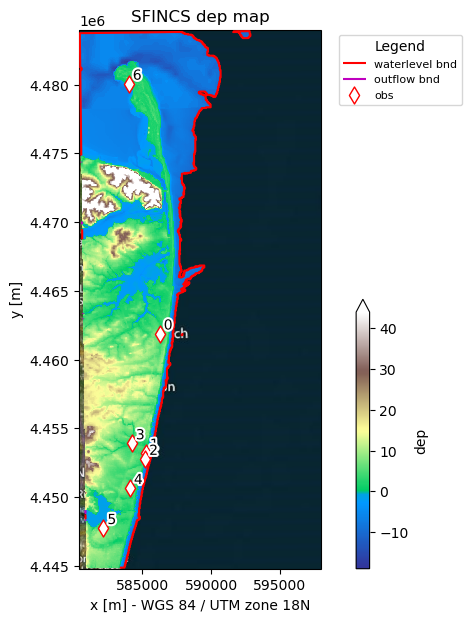

In [3]:
# Plot the model layout — grid, boundary cells, and observation points
fig, ax = mod.plot_basemap(fn_out=None, bmap="sat", figsize=(9, 7), geom_names=["obs"])

### Diagnostic: peak water level, dune freeboard, and where the surge went

Two cells below evaluate each run:
- **Peak table** — per obs point: local `zb`, modeled peak `zs`, freeboard (`zb − zs`; negative = overtopped), and a model-vs-observed delta where a gauge value is known (`sandy_hook_gauge`).
- **Zone stats** — peak `zs` binned by topographic zone, with how many cells in each zone ever got wet (now that rainfall is on, every cell wets by at least a thin film, so watch the *depth* not just the wet count).

`NOAA_PEAKS_NAVD88` only carries `sandy_hook_gauge` — it's the one obs point that sits on a real gauge. The other obs points are interior monitoring locations, not gauges, so there's nothing to compare them against (the USGS HWMs in Phase 3 provide the spatial validation instead).

In [4]:
# Sandy peak still-water levels at NOAA gauges (m NAVD88), used to validate
# obs points that sit ON or NEAR a known gauge. `sandy_hook_gauge` is the
# direct validation point — its 3.86 m value is the canonical peak storm tide
# (gauge failed mid-storm; The Battery, ~5 km north, recorded 3.42 m and is
# generally cited as a lower bound for Sandy Hook's peak).
NOAA_PEAKS_NAVD88 = {
    "sandy_hook_gauge": 3.86,   # 8531680 (canonical Sandy peak storm tide)
}

point_zs = mod.output.data["point_zs"]   # (time, station)
point_zb = mod.output.data["point_zb"]   # (station,)
names = [n.decode() if isinstance(n, bytes) else str(n)
         for n in point_zs["station_name"].values]

rows = []
for i, name in enumerate(names):
    zs_ts = point_zs.isel(stations=i)
    zb = float(point_zb.isel(stations=i).values)
    zs_peak = float(zs_ts.max().values)
    t_peak = pd.Timestamp(zs_ts["time"].values[int(zs_ts.argmax().values)])
    freeboard = zb - zs_peak  # +ve = dune stayed dry, -ve = overtopped
    rows.append({
        "obs_point": name,
        "zb [m]": round(zb, 2),
        "modeled zs_peak [m]": round(zs_peak, 2),
        "t_peak [UTC]": t_peak.strftime("%m-%d %H:%M"),
        "freeboard zb-zs [m]": round(freeboard, 2),
        "NOAA peak [m]": NOAA_PEAKS_NAVD88.get(name, None),
        "model - NOAA [m]": (round(zs_peak - NOAA_PEAKS_NAVD88[name], 2)
                              if name in NOAA_PEAKS_NAVD88 else None),
    })

print(pd.DataFrame(rows))

                                           obs_point  zb [m]  \
0  long_branch_beach                             ...    3.77   
1  asbury_park_pier                              ...    2.40   
2  deal_lake_outlet                              ...   -0.08   
3  deal_lake_interior                            ...    0.23   
4  bradley_beach                                 ...    4.56   
5  shark_river_inlet                             ...    3.42   
6  sandy_hook_gauge                              ...   -2.00   

   modeled zs_peak [m] t_peak [UTC]  freeboard zb-zs [m] NOAA peak [m]  \
0                 3.84  10-29 18:40                -0.07          None   
1                 3.74  10-30 00:00                -1.34          None   
2                 3.73  10-30 00:00                -3.81          None   
3                 1.81  10-31 00:00                -1.58          None   
4                 4.67  10-29 18:50                -0.10          None   
5                 5.99  10-30 03:10        

In [5]:
# Where did the surge actually go? For each topographic zone, report:
#   - n_cells: how many grid cells have zb in that band (regardless of wetting)
#   - n_wet: how many of those cells ever saw water (zsmax not NaN)
#   - peak zs stats over the wet subset
zsmax = mod.output.data["zsmax"].max(dim="timemax")
zb_grid = mod.output.data["zb"]
msk = mod.output.data["msk"]

def stats(label, mask):
    n_cells = int(mask.sum().values)
    vals = zsmax.where(mask).values
    vals = vals[~pd.isna(vals)]
    n_wet = len(vals)
    if n_cells == 0:
        print(f"{label:30s}  (no cells in this zone)")
        return
    if n_wet == 0:
        print(f"{label:30s}  n_cells={n_cells:6d}  n_wet=0  (zone stayed dry)")
        return
    s = pd.Series(vals)
    print(f"{label:30s}  n_cells={n_cells:6d}  n_wet={n_wet:6d}  "
          f"median={s.median():.2f}  p95={s.quantile(0.95):.2f}  "
          f"max={s.max():.2f}  [m NAVD88]")

print("Peak zs across the grid, by zone:")
stats("offshore bnd (mask==2)",     msk == 2)
stats("deep shelf  (zb < -5)",       zb_grid < -5)
stats("nearshore   (-5 < zb < -1)",  (zb_grid > -5) & (zb_grid < -1))
stats("surf zone   (-1 < zb < 0)",   (zb_grid > -1) & (zb_grid < 0))
stats("beach/dune  ( 0 < zb < 3)",   (zb_grid > 0)  & (zb_grid < 3))
stats("upper dune  ( 3 < zb < 6)",   (zb_grid > 3)  & (zb_grid < 6))
stats("inland low  ( 6 < zb < 15)",  (zb_grid > 6)  & (zb_grid < 15))

Peak zs across the grid, by zone:
offshore bnd (mask==2)          n_cells=  1370  n_wet=  1370  median=3.88  p95=3.99  max=3.99  [m NAVD88]
deep shelf  (zb < -5)           n_cells= 31839  n_wet= 31839  median=3.96  p95=4.01  max=6.00  [m NAVD88]
nearshore   (-5 < zb < -1)      n_cells= 11719  n_wet= 11719  median=3.89  p95=5.96  max=8.15  [m NAVD88]
surf zone   (-1 < zb < 0)       n_cells=  2360  n_wet=  2349  median=3.71  p95=6.04  max=6.36  [m NAVD88]
beach/dune  ( 0 < zb < 3)       n_cells= 13273  n_wet= 13271  median=3.37  p95=5.36  max=6.26  [m NAVD88]
upper dune  ( 3 < zb < 6)       n_cells= 11971  n_wet= 11971  median=4.80  p95=6.02  max=7.08  [m NAVD88]
inland low  ( 6 < zb < 15)      n_cells= 20294  n_wet= 20294  median=9.29  p95=14.35  max=16.68  [m NAVD88]


### Validation: modeled vs observed water level at Sandy Hook

`noaa_sandy_validation.nc` carries the Sandy Hook gauge (8531680) — the record up to the gauge failure at 10-29 23:00. This is the one place inside the domain with an independent observed time series, so it's the cleanest check on whether the NOAA-driven boundary reproduces the storm tide. The gap between the two curves before 10-29 23:00 is the model error to close (surge magnitude + missing wave setup).

observed peak (pre-failure): 2.81 m NAVD88
modeled  peak (same window): 3.38 m NAVD88
modeled  peak (full run):    3.93 m NAVD88


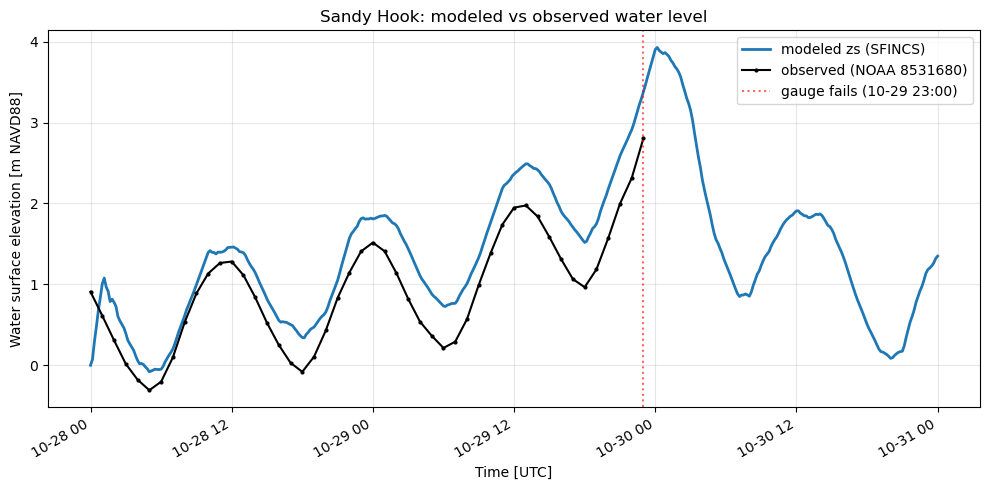

In [6]:
# Modeled zs at the sandy_hook_gauge obs point vs the observed NOAA record.
val = xr.open_dataset("/home/zagreus/nj_sandy_sfincs/data/gtsm/noaa_sandy_validation.nc")
obs_sh = val["waterlevel"].sel(stations=8531680)

# locate the sandy_hook_gauge obs point (names may carry trailing padding)
i_sh = next(k for k, n in enumerate(names) if "sandy_hook" in n)
mod_sh = point_zs.isel(stations=i_sh)
zb_sh = float(point_zb.isel(stations=i_sh).values)
mod_sh_wet = mod_sh.where(mod_sh - zb_sh > 0.01)  # only where the cell is wet

# peak comparison over the window the gauge actually covers
gauge_end = pd.Timestamp("2012-10-29 23:00")
mod_overlap = mod_sh.sel(time=slice(None, gauge_end))
print(f"observed peak (pre-failure): {float(obs_sh.max()):.2f} m NAVD88")
print(f"modeled  peak (same window): {float(mod_overlap.max()):.2f} m NAVD88")
print(f"modeled  peak (full run):    {float(mod_sh.max()):.2f} m NAVD88")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mod_sh["time"], mod_sh_wet.values, lw=2, label="modeled zs (SFINCS)")
ax.plot(obs_sh["time"], obs_sh.values, "k.-", ms=4, label="observed (NOAA 8531680)")
ax.axvline(gauge_end, color="red", ls=":", alpha=0.6, label="gauge fails (10-29 23:00)")
ax.set_ylabel("Water surface elevation [m NAVD88]")
ax.set_xlabel("Time [UTC]")
ax.set_title("Sandy Hook: modeled vs observed water level")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()

### 2. Downscale Flood Map

In [7]:
# Reuse `mod` opened above — no need to open a second SfincsModel
da_zsmax = mod.output.data["zsmax"].max(dim="timemax")

# Load the high-res subgrid DEM (written during build via write_dep_tif=True)
depfile = str(model_abs / "subgrid" / "dep_subgrid.tif")
da_dep = mod.data_catalog.get_rasterdataset(depfile)
print(f"Subgrid DEM shape: {da_dep.shape}, resolution: {da_dep.rio.resolution()}")

# Downscale water level to subgrid resolution, then drop deep-ocean cells
# (dep > -0.5) so the open shelf doesn't dominate the flood-map colour scale.
da_hmax = utils.downscale_floodmap(zsmax=da_zsmax, dep=da_dep, hmin=0.05)
da_hmax = da_hmax.where(da_dep > -0.5)

2026-05-20 14:25:21,231 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading dep_subgrid.tif RasterDataset data from /home/zagreus/nj_sandy_sfincs/model/subgrid/dep_subgrid.tif


Subgrid DEM shape: (6224, 2728), resolution: (6.249566282166736, 6.249566282166805)


### Validation: USGS High Water Marks (spatial — "more or less than Sandy?")

The Sandy Hook gauge is a single point that failed mid-storm. For a *spatial* answer to "are we flooding more or less than Sandy actually did?", we compare modeled peak water level against **USGS High Water Marks** — surveyed peak water-surface elevations (mud/seed lines, interior-wall marks) in NAVD88 from the Sandy rapid-response survey (USGS STN Flood Event Viewer, event 24). **31 marks fall inside the domain** (all coastal, NAVD88, 2.9–5.79 m), downloaded by `scripts/download_sandy_hwms.py` -> `data/validation/sandy_hwms.geojson`.

Each mark is compared to the **wettest modeled cell within a 50 m radius** of the mark. The radius matters: at the 6 m downscaled resolution the *nearest* pixel often lands on the building/raised lot the mark sits on (which reads as dry), so we take the nearby flooded street/yard instead. Residual sign: **+ = model higher than observed (over-predict)**. We report the quality<=3 subset (drops the 5 poorest survey marks) as the headline.

model wet at 25/31 HWMs (sign: + = model over-predicts)
all wet            : n=25  mean=+0.25 m  median=+0.21  RMSE=1.56  within +/-0.5 m=44%
quality<=3 & wet   : n=21  mean=-0.02 m  median=+0.17  RMSE=0.92  within +/-0.5 m=48%
model DRY at 6 HWMs (local under-prediction)


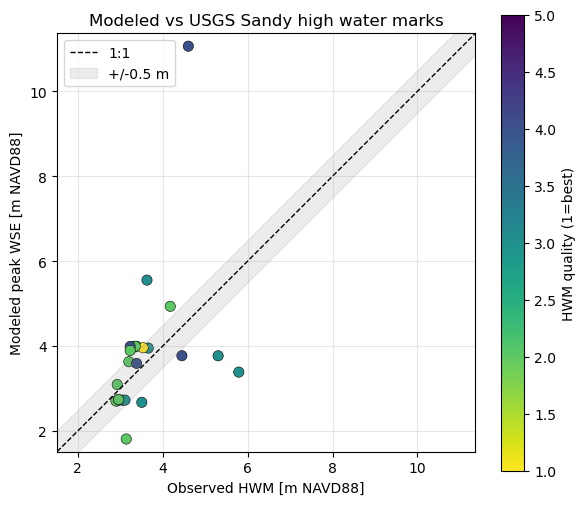

In [8]:
# Compare modeled peak water level vs USGS Sandy High Water Marks.
# Reuses da_dep + da_hmax from the downscale cell above (peak WSE = dep + depth).
import numpy as np

hwm = gpd.read_file("/home/zagreus/nj_sandy_sfincs/data/validation/sandy_hwms.geojson")
hwm = hwm.to_crs(da_dep.rio.crs)

wse = (da_dep + da_hmax).values            # modeled peak water-surface elev (NAVD88)
if wse.ndim == 3:
    wse = wse[0]
T = da_dep.rio.transform()
ny, nx = wse.shape
res = abs(T.a)
rad = int(round(50 / res))                 # ~50 m search radius

obs = hwm["elev_m"].values
qual = hwm["quality"].values.astype(float)
mod_wse = np.full(len(obs), np.nan)
for k, (X, Y) in enumerate(zip(hwm.geometry.x.values, hwm.geometry.y.values)):
    col = int((X - T.c) / T.a)
    row = int((Y - T.f) / T.e)
    if 0 <= row < ny and 0 <= col < nx:
        win = wse[max(0, row - rad):row + rad + 1, max(0, col - rad):col + rad + 1]
        if np.isfinite(win).any():
            mod_wse[k] = np.nanmax(win)

wet = np.isfinite(mod_wse)
resid = mod_wse - obs                       # + = model higher than observed
def report(label, m):
    r = resid[m]
    if m.sum() == 0:
        print(f"{label}: (no points)"); return
    print(f"{label}: n={int(m.sum())}  mean={np.mean(r):+.2f} m  median={np.median(r):+.2f}  "
          f"RMSE={np.sqrt(np.mean(r**2)):.2f}  within +/-0.5 m={np.mean(np.abs(r)<0.5)*100:.0f}%")

print(f"model wet at {wet.sum()}/{len(obs)} HWMs (sign: + = model over-predicts)")
report("all wet            ", wet)
report("quality<=3 & wet   ", wet & (qual <= 3))
print(f"model DRY at {int((~wet).sum())} HWMs (local under-prediction)")

# scatter: modeled vs observed, 1:1 line, colored by survey quality
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(obs[wet], mod_wse[wet], c=qual[wet], cmap="viridis_r", s=55,
                edgecolor="k", linewidth=0.4, vmin=1, vmax=5)
lim = [min(obs[wet].min(), np.nanmin(mod_wse[wet])) - 0.3,
       max(obs[wet].max(), np.nanmax(mod_wse[wet])) + 0.3]
ax.plot(lim, lim, "k--", lw=1, label="1:1")
ax.fill_between(lim, [l - 0.5 for l in lim], [l + 0.5 for l in lim],
                color="grey", alpha=0.15, label="+/-0.5 m")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel("Observed HWM [m NAVD88]")
ax.set_ylabel("Modeled peak WSE [m NAVD88]")
ax.set_title("Modeled vs USGS Sandy high water marks")
fig.colorbar(sc, ax=ax, shrink=0.8, label="HWM quality (1=best)")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout()

### Validation map: where does the model over/under-predict?

The same 31 HWMs plotted on the flood map, colored by **residual (model − observed)**: red = model higher than the mark, blue = model lower, black × = the mark stayed dry in the model (local under-prediction). This shows *where* the misfit is — useful for spotting whether the dry marks cluster (e.g. along a back-bay shore the still-water boundary doesn't reach) versus scattering randomly (resolution noise).

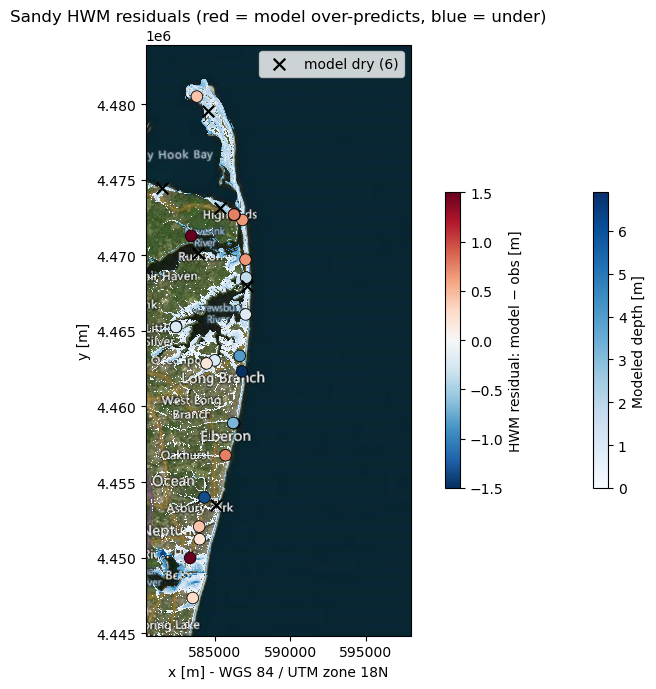

In [9]:
# HWM residuals on the flood map (reuses hwm, resid, wet from the cell above).
import numpy as np

fig, ax = mod.plot_basemap(
    fn_out=None, figsize=(9, 7), variable=da_hmax,
    plot_bounds=False, plot_geoms=False, bmap="sat", zoomlevel=11,
    vmin=0, cmap="Blues", cbar_kwargs={"shrink": 0.5, "label": "Modeled depth [m]"},
)
hx, hy = hwm.geometry.x.values, hwm.geometry.y.values
sc = ax.scatter(hx[wet], hy[wet], c=resid[wet], cmap="RdBu_r", vmin=-1.5, vmax=1.5,
                s=70, edgecolor="k", linewidth=0.6, zorder=5)
ax.scatter(hx[~wet], hy[~wet], marker="x", color="k", s=70, linewidth=1.6,
           zorder=6, label=f"model dry ({int((~wet).sum())})")
fig.colorbar(sc, ax=ax, shrink=0.5, label="HWM residual: model − obs [m]")
ax.legend(loc="upper right")
ax.set_title("Sandy HWM residuals (red = model over-predicts, blue = under)")
plt.tight_layout()

Text(0.5, 1.0, 'SFINCS maximum water depth')

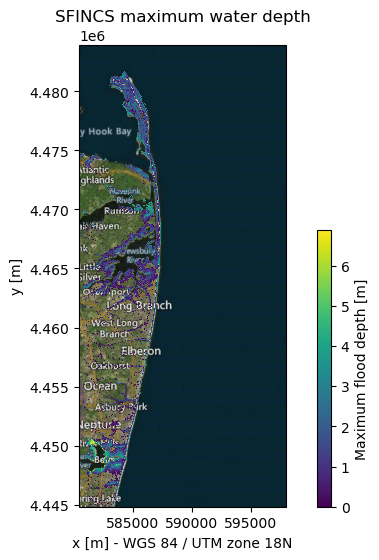

In [10]:
fig, ax = mod.plot_basemap(
    fn_out=None,
    figsize=(8, 6),
    variable=da_hmax,
    plot_bounds=False,
    plot_geoms=False,
    bmap="sat",
    zoomlevel=11,
    vmin=0,
    # vmax=3.0,
    cbar_kwargs={"shrink": 0.6, "anchor": (0, 0)},
)
ax.set_title(f"SFINCS maximum water depth")

In [11]:
# Reload obs points from the written model (gis/obs.geojson) rather than
# relying on `obs_all` from the Phase 1 build cell — keeps the Visualization
# section runnable standalone after a kernel restart.
obs_all = gpd.read_file(model_abs / "gis" / "obs.geojson")

flood_wgs84 = da_hmax.where(da_hmax > 0.05).rio.reproject(
    "EPSG:4326", nodata=float("nan")
)

flood_map = flood_wgs84.hvplot.image(
    x="x", y="y",
    cmap="viridis",
    clim=(0, 3),
    geo=True,
    tiles="EsriImagery",
    alpha=0.75,
    width=900, height=700,
    title="Max flood depth — Sandy (NOAA gauges + ERA5 + Stockdon setup + AORC rain + USGS discharge)",
    clabel="Flood depth [m]",
)

obs_layer = obs_all.hvplot.points(
    geo=True, color="red", size=60,
    hover_cols=["name"],
)

flood_map * obs_layer

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Image.I  :Image   [x,y]   (Maximum flood depth)
   .Points.I :Points   [Longitude,Latitude]   (name)